# EDA: hospedagem e criminalidade em Rio de Janeiro

Análise exploratória conjunta dos datasets de Airbnb e crimes.

In [5]:
from pathlib import Path
%pip install -q geopandas
import geopandas as gpd
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data").is_dir()
)
DATA_DIR = PROJECT_ROOT / "data"


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
listings = pd.read_csv("../../data/listings.csv")
listings

/var/folders/y_/fwgr_vwd23l50tn1dxwsf85r0000gn/T/ipykernel_3448/3338355115.py:1: DtypeWarning: Columns (11,35,36,37,40,77,78,79,80,81,82,83,85,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("../../data/listings.csv")


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,host_total_listings_count,host_verifications,neighbourhood,instant_bookable
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,20260624212719,2026-06-25,city scrape,Quartos disponíveis no Recreio,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,546603190,https://www.airbnb.com/users/show/546603190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,20260624212719,2026-06-25,city scrape,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,https://a0.muscache.com/pictures/hosting/Hosti...,737983482,https://www.airbnb.com/users/show/737983482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,42874066,https://www.airbnb.com/rooms/42874066,20260624212719,2026-06-25,city scrape,Alugo uma vaga para sexo feminino Recreio,NaN,https://a0.muscache.com/pictures/43e779d6-58df...,341395950,https://www.airbnb.com/users/show/341395950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,20260624212719,2026-06-26,previous scrape,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,173836079,https://www.airbnb.com/users/show/173836079,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,20260624212719,2026-06-25,city scrape,Suíte Rio BR,Spacious and pleasant suite in a family home.,https://a0.muscache.com/pictures/miso/Hosting-...,69238992,https://www.airbnb.com/users/show/69238992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179632,1651790928149305935,https://www.airbnb.com/rooms/1651790928149305935,20260330062336,2026-04-02,city scrape,Av. Atlântica | Vista Mar Incrível | Suíte Premi,"Comfortable sea-facing suite in Copacabana, on...",https://a0.muscache.com/pictures/hosting/Hosti...,357078569,https://www.airbnb.com/users/show/357078569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179633,1652082025241101165,https://www.airbnb.com/rooms/1652082025241101165,20260330062336,2026-04-02,city scrape,Copacabana: Praia e Conforto | 5 Hóspedes,NaN,https://a0.muscache.com/pictures/prohost-api/H...,12335830,https://www.airbnb.com/users/show/12335830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179634,1652148096386184589,https://www.airbnb.com/rooms/1652148096386184589,20260330062336,2026-04-02,city scrape,Amplo e bem localizado Apê em Copacabana,"Spacious apartment in Copacabana, just minutes...",https://a0.muscache.com/pictures/hosting/Hosti...,513633037,https://www.airbnb.com/users/show/513633037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179635,1652264749683808805,https://www.airbnb.com/rooms/1652264749683808805,20260330062336,2026-04-02,city scrape,Apartamento para trabalho e para casal,Keep it simple at this peaceful and centrally-...,https://a0.muscache.com/pictures/hosting/Hosti...,754155809,https://www.airbnb.com/users/show/754155809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
crimes = pd.read_csv("../../data/crime_data/BaseDPEvolucaoMensalCisp.csv", encoding="latin-1", sep=";")
crimes

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38131,159,7,2026,2026m07,11,7,Cachoeiras de Macacu,3300803,Interior,0,...,3.0,0.0,21,3,0,0,0,0,148,2
38132,165,7,2026,2026m07,33,5,Mangaratiba,3302601,Interior,2,...,8.0,0.0,40,1,0,0,0,0,180,2
38133,166,7,2026,2026m07,33,5,Angra dos Reis,3300100,Interior,3,...,21.0,3.0,96,4,0,0,0,0,710,2
38134,167,7,2026,2026m07,43,5,Paraty,3303807,Capital,1,...,3.0,0.0,27,2,1,0,0,0,206,2


In [9]:
cisp = gpd.read_file(
    "../../data/shape_file/CISPshp/CISPshp/cisp.shp"
)

aisp = gpd.read_file(
    "../../data/shape_file/AISPshp/SHP/aisp.shp"
)

risp = gpd.read_file(
    "../../data/shape_file/RISPshp/RISPshp/risp.shp"
)

# Merge Datasets

In [15]:
# Crimes - mes a mes - CISP, AISP e RISP
# Listings - snapshots trimestrais com coordenadas
# Shapefiles - CISP, AISP e RISP


def normalize_area_id(frame, columns):
    frame = frame.copy()
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce").astype("Int64")
    return frame


# Padroniza as chaves espaciais antes dos merges.
area_columns = ["cisp", "aisp", "risp"]
crimes = normalize_area_id(crimes, area_columns)
cisp = normalize_area_id(cisp, ["cisp", "aisp"])
aisp = normalize_area_id(aisp, ["aisp", "risp"])
risp = normalize_area_id(risp, ["risp"])

# Base mensal de crimes por CISP, mantendo AISP e RISP como chaves de análise.
crime_value_columns = crimes.select_dtypes(include="number").columns.difference(
    ["cisp", "aisp", "risp", "mes", "ano"]
).tolist()
crimes_monthly = (
    crimes.groupby(["cisp", "aisp", "risp", "mes", "ano"], dropna=False)[crime_value_columns]
    .sum(min_count=1)
    .reset_index()
)
crimes_monthly["trimestre"] = ((crimes_monthly["mes"] - 1) // 3 + 1).astype("Int64")

# Agrega os crimes mensais ao trimestre dos snapshots de listings.
crime_quarter_columns = ["cisp", "aisp", "risp", "ano", "trimestre"]
crimes_quarterly = (
    crimes_monthly.groupby(crime_quarter_columns, dropna=False)[crime_value_columns]
    .sum(min_count=1)
    .reset_index()
    .rename(columns={column: f"crime_{column}" for column in crime_value_columns})
)

# Converte os listings em pontos e identifica o trimestre pelo last_scraped.
listing_points = listings.copy()
listing_points["snapshot_date"] = pd.to_datetime(
    listing_points["last_scraped"], errors="coerce"
)
listing_points["ano"] = listing_points["snapshot_date"].dt.year.astype("Int64")
listing_points["trimestre"] = listing_points["snapshot_date"].dt.quarter.astype("Int64")
listing_points = listing_points.dropna(subset=["latitude", "longitude"])
listing_points = gpd.GeoDataFrame(
    listing_points,
    geometry=gpd.points_from_xy(listing_points["longitude"], listing_points["latitude"]),
    crs="EPSG:4326",
)

# Localiza cada listing nas três divisões administrativas.
listings_cisp = gpd.sjoin(
    listing_points,
    cisp[["cisp", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")
listings_cisp = gpd.sjoin(
    listings_cisp,
    aisp[["aisp", "geometry"]],
    how="left",
    predicate="within",
    lsuffix="listing",
    rsuffix="aisp",
).drop(columns=["index_right"], errors="ignore")
listings_cisp = gpd.sjoin(
    listings_cisp,
    risp[["risp", "geometry"]],
    how="left",
    predicate="within",
    lsuffix="listing",
    rsuffix="risp",
).drop(columns=["index_right"], errors="ignore")

# Remove a geometria antes do merge tabular com os crimes trimestrais.
listings_crimes = listings_cisp.drop(columns="geometry", errors="ignore").merge(
    crimes_quarterly,
    on=["cisp", "aisp", "risp", "ano", "trimestre"],
    how="left",
    validate="many_to_one",
)

print(f"Dimensão de listings_crimes: {listings_crimes.shape[0]:,} linhas x {listings_crimes.shape[1]} colunas")
listings_crimes.head(50)

Dimensão de listings_crimes: 179,637 linhas x 153 colunas


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,crime_roubo_rua,crime_roubo_transeunte,crime_roubo_veiculo,crime_sequestro,crime_sequestro_relampago,crime_tentat_hom,crime_tentativa_feminicidio,crime_total_furtos,crime_total_roubos,crime_trafico_drogas
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,20260624212719,2026-06-25,city scrape,Quartos disponíveis no Recreio,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,546603190,https://www.airbnb.com/users/show/546603190,...,180.0,91.0,43.0,0.0,0.0,22.0,0.0,786.0,300.0,33.0
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,20260624212719,2026-06-25,city scrape,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,https://a0.muscache.com/pictures/hosting/Hosti...,737983482,https://www.airbnb.com/users/show/737983482,...,233.0,112.0,46.0,0.0,0.0,1.0,1.0,794.0,372.0,8.0
2,42874066,https://www.airbnb.com/rooms/42874066,20260624212719,2026-06-25,city scrape,Alugo uma vaga para sexo feminino Recreio,NaN,https://a0.muscache.com/pictures/43e779d6-58df...,341395950,https://www.airbnb.com/users/show/341395950,...,180.0,91.0,43.0,0.0,0.0,22.0,0.0,786.0,300.0,33.0
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,20260624212719,2026-06-26,previous scrape,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,173836079,https://www.airbnb.com/users/show/173836079,...,366.0,236.0,38.0,0.0,3.0,4.0,0.0,1550.0,571.0,11.0
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,20260624212719,2026-06-25,city scrape,Suíte Rio BR,Spacious and pleasant suite in a family home.,https://a0.muscache.com/pictures/miso/Hosting-...,69238992,https://www.airbnb.com/users/show/69238992,...,223.0,117.0,117.0,0.0,0.0,0.0,0.0,344.0,383.0,7.0
5,1480784189647065903,https://www.airbnb.com/rooms/1480784189647065903,20260624212719,2026-06-26,city scrape,aluguel por temporada,Enjoy a stylish experience at this centrally-l...,https://a0.muscache.com/pictures/hosting/Hosti...,257454960,https://www.airbnb.com/users/show/257454960,...,121.0,57.0,1.0,0.0,1.0,2.0,0.0,1570.0,138.0,9.0
6,1224220304015172939,https://www.airbnb.com/rooms/1224220304015172939,20260624212719,2026-06-25,city scrape,Copacabana 800metros praia leme,ou'll have a great time at this comfortable pl...,https://a0.muscache.com/pictures/hosting/Hosti...,260411129,https://www.airbnb.com/users/show/260411129,...,121.0,57.0,1.0,0.0,1.0,2.0,0.0,1570.0,138.0,9.0
7,1461158564043665719,https://www.airbnb.com/rooms/1461158564043665719,20260624212719,2026-07-01,previous scrape,Apartamento em frente a praia,Apartment in front of Copacabana beach at post...,https://a0.muscache.com/pictures/hosting/Hosti...,366565166,https://www.airbnb.com/users/show/366565166,...,10.0,6.0,0.0,0.0,0.0,0.0,0.0,207.0,12.0,2.0
8,1348392694164191680,https://www.airbnb.com/rooms/1348392694164191680,20260624212719,2026-07-01,previous scrape,Loft a 5min da Praia,"Embrace simplicity in this well-located place,...",https://a0.muscache.com/pictures/hosting/Hosti...,54999532,https://www.airbnb.com/users/show/54999532,...,66.0,34.0,0.0,0.0,0.0,0.0,0.0,458.0,75.0,3.0
9,1015045,https://www.airbnb.com/rooms/1015045,20260624212719,2026-06-26,city scrape,ipa vis 506,NaN,https://a0.muscache.com/pictures/15261868/7a5b...,4307081,https://www.airbnb.com/users/show/4307081,...,170.0,84.0,0.0,0.0,1.0,1.0,0.0,1367.0,201.0,2.0


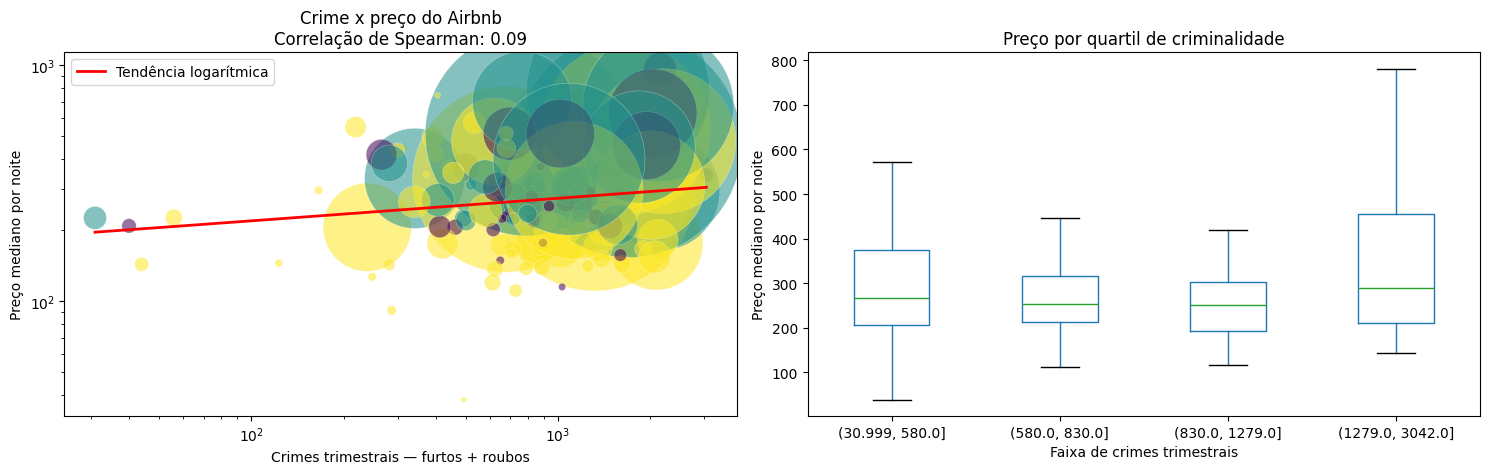

,cisp,ano,trimestre,preco_mediano,anuncios,crime_total,faixa_crime
28,11,2026,2,225.62,91,31.0,"(30.999, 580.0]"
27,11,2026,1,208.75,36,40.0,"(30.999, 580.0]"
26,11,2025,3,143.5,34,44.0,"(30.999, 580.0]"
17,7,2026,3,226.3,50,56.0,"(30.999, 580.0]"
128,37,2026,3,145.0,10,123.0,"(30.999, 580.0]"


In [17]:
import numpy as np

import matplotlib.pyplot as plt

df = listings_crimes.copy()

# Converte o preço para número.
df["preco_noite"] = pd.to_numeric(
    df["price_quote_price_per_night"], errors="coerce"
)

preco_fallback = (
    df["price"]
    .astype("string")
    .str.replace(r"[$,]", "", regex=True)
)
df["preco_noite"] = df["preco_noite"].fillna(
    pd.to_numeric(preco_fallback, errors="coerce")
)

# Indicador de criminalidade: furtos + roubos trimestrais.
df["crime_total"] = (
    df["crime_total_furtos"].fillna(0)
    + df["crime_total_roubos"].fillna(0)
)

# Agrega anúncios por área e período.
analise = (
    df.dropna(subset=["preco_noite", "crime_total", "cisp"])
    .query("preco_noite > 0")
    .groupby(["cisp", "ano", "trimestre"], as_index=False)
    .agg(
        preco_mediano=("preco_noite", "median"),
        anuncios=("id", "nunique"),
        crime_total=("crime_total", "first"),
    )
)

# Mantém áreas com quantidade mínima de anúncios.
analise = analise.query("anuncios >= 5").copy()

# Correlação entre crime e preço.
# Correlação de Spearman sem depender do scipy.
crime_rank = analise["crime_total"].rank(method="average")
preco_rank = analise["preco_mediano"].rank(method="average")

correlacao = crime_rank.corr(preco_rank, method="pearson")

# Regressão no espaço logarítmico.
x = np.log1p(analise["crime_total"])
y = np.log1p(analise["preco_mediano"])
coef = np.polyfit(x, y, 1)
linha_x = np.linspace(x.min(), x.max(), 100)
linha_y = np.polyval(coef, linha_x)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Relação entre criminalidade e preço.
axes[0].scatter(
    analise["crime_total"],
    analise["preco_mediano"],
    s=analise["anuncios"] * 3,
    alpha=0.55,
    c=analise["trimestre"],
    cmap="viridis",
    edgecolor="white",
    linewidth=0.3,
)

axes[0].plot(
    np.expm1(linha_x),
    np.expm1(linha_y),
    color="red",
    linewidth=2,
    label="Tendência logarítmica",
)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Crimes trimestrais — furtos + roubos")
axes[0].set_ylabel("Preço mediano por noite")
axes[0].set_title(
    f"Crime x preço do Airbnb\nCorrelação de Spearman: {correlacao:.2f}"
)
axes[0].legend()

# Distribuição de preços por nível de criminalidade.
analise["faixa_crime"] = pd.qcut(
    analise["crime_total"],
    q=4,
    duplicates="drop",
)

analise.boxplot(
    column="preco_mediano",
    by="faixa_crime",
    ax=axes[1],
    grid=False,
    showfliers=False,
)

axes[1].set_title("Preço por quartil de criminalidade")
axes[1].set_xlabel("Faixa de crimes trimestrais")
axes[1].set_ylabel("Preço mediano por noite")
plt.suptitle("")
plt.tight_layout()
plt.show()

analise.sort_values("crime_total").head()

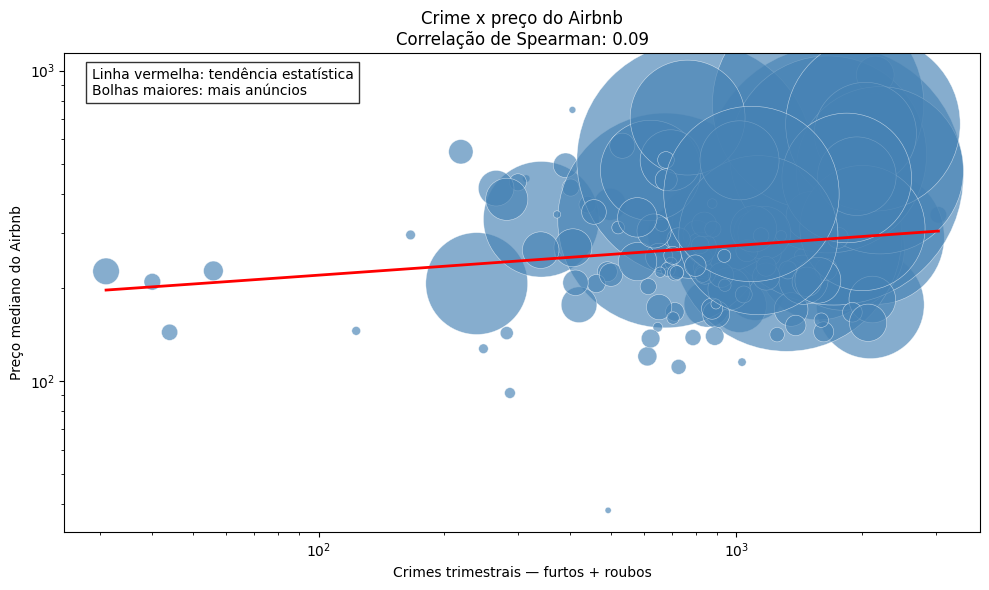

Resultado: associação fraca — não há evidência clara de relação entre crime e preço.
Atenção: este gráfico não prova que o crime causa alterações no preço.


In [19]:
# Relação entre criminalidade e preço, em escala logarítmica
grafico = analise.dropna(subset=["crime_total", "preco_mediano"]).copy()
grafico = grafico[
    (grafico["crime_total"] >= 0) &
    (grafico["preco_mediano"] > 0)
]

x_grafico = np.log1p(grafico["crime_total"])
y_grafico = np.log1p(grafico["preco_mediano"])

coef_grafico = np.polyfit(x_grafico, y_grafico, 1)
linha_x_grafico = np.linspace(x_grafico.min(), x_grafico.max(), 100)
linha_y_grafico = np.polyval(coef_grafico, linha_x_grafico)

# Correlação de Spearman sem depender do scipy.
crime_rank_grafico = x_grafico.rank(method="average")
preco_rank_grafico = y_grafico.rank(method="average")

correlacao_grafico = crime_rank_grafico.corr(
    preco_rank_grafico,
    method="pearson",
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    grafico["crime_total"],
    grafico["preco_mediano"],
    s=grafico["anuncios"] * 4,
    alpha=0.65,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
)

ax.plot(
    np.expm1(linha_x_grafico),
    np.expm1(linha_y_grafico),
    color="red",
    linewidth=2,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Crimes trimestrais — furtos + roubos")
ax.set_ylabel("Preço mediano do Airbnb")
ax.set_title(
    f"Crime x preço do Airbnb\n"
    f"Correlação de Spearman: {correlacao_grafico:.2f}"
)

ax.text(
    0.03,
    0.97,
    "Linha vermelha: tendência estatística\n"
    "Bolhas maiores: mais anúncios",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

if correlacao_grafico < -0.2:
    print("Resultado: associação negativa — maior criminalidade está associada a menor preço.")
elif correlacao_grafico > 0.2:
    print("Resultado: associação positiva — maior criminalidade está associada a maior preço.")
else:
    print("Resultado: associação fraca — não há evidência clara de relação entre crime e preço.")

print("Atenção: este gráfico não prova que o crime causa alterações no preço.")